# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn \
    lime shap opencv-python \
    python-dotenv kaggle \
    optuna optuna-dashboard optuna-integration


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

True

## 2: Configuración de la GPU y librerías

In [3]:
import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf

# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-04-30 04:54:45.857907: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 04:54:46.647310: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-04-30 04:54:48.077662: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:48.243618: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:48.243666: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [4]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"


# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES (Tu código original)
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS (Nueva sección)
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    # Usamos -p para indicar la carpeta de destino
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/herraiz/proyectos/TFM/datasets/ham10000/HAM10000_metadata.csv.
��� Proceso completo. Imágenes y metadatos preparados en /home/herraiz/proyectos/TFM/datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [5]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Cargar metadatos
df = pd.read_csv(META_PATH)

# 2. Preprocesamiento de Metadatos
# Rellenar edades faltantes con la media
df['age'] = df['age'].fillna(df['age'].mean())

# Encoding: Sexo y Localización (Categorical) + Edad (Escalada)
encoder = OneHotEncoder(sparse_output=False)
cat_features = encoder.fit_transform(df[['sex', 'localization']])
scaler = StandardScaler()
num_features = scaler.fit_transform(df[['age']])

# Combinar todas las características numéricas en un solo array
meta_array = np.hstack([num_features, cat_features]).astype(np.float32)
df_meta_ready = pd.DataFrame(meta_array, index=df['image_id'])

# 3. Mapeo de rutas de archivos
# Buscamos todas las imágenes .jpg en las subcarpetas
all_image_paths = []
all_labels = []
all_meta = []

class_names = sorted(os.listdir(DATA_PATH))  

# Mapeo inverso: Nombre de carpeta -> ID numérico (basado en el orden de class_names)
# 'class_names' viene de tu carpeta: ['Actinic Keratoses', 'Basal Cell Carcinoma', ...]
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df_meta_ready.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_meta.append(df_meta_ready.loc[img_id].values)

# 4. Split de entrenamiento y validación (Stratified para mantener proporciones)
train_paths, val_paths, train_meta, val_meta, train_labels, val_labels = train_test_split(
    all_image_paths, all_meta, all_labels, test_size=0.2, random_state=123, stratify=all_labels
)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           10015 non-null  float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Creamos la función que leerá tanto la imagen como los metadatos

In [8]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


2026-04-30 04:54:48.846121: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:48.846209: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:48.846228: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:49.189115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-30 04:54:49.189172: I external/local_xla/xla/stream_executor

## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


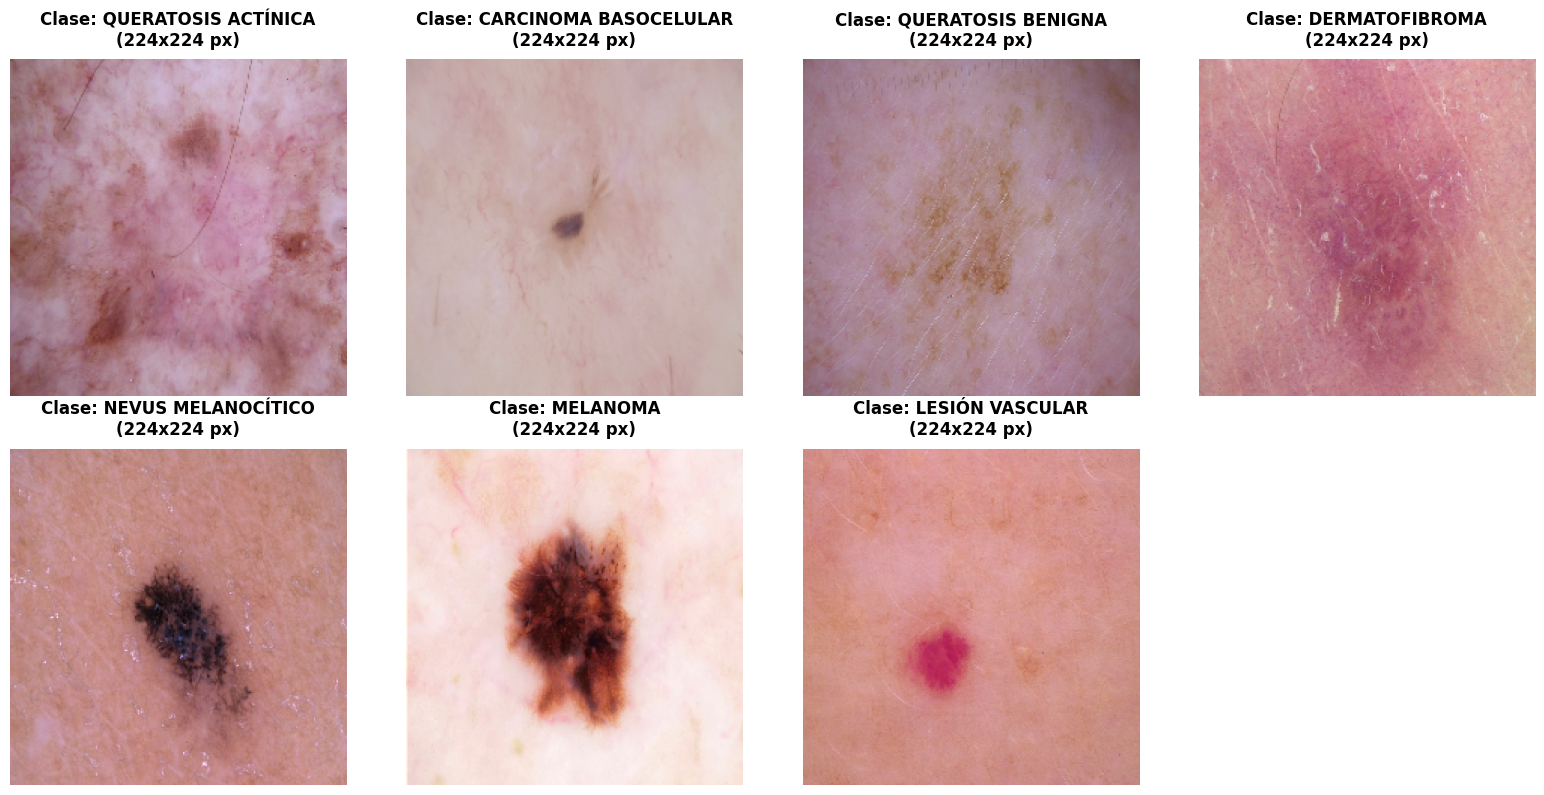

In [9]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

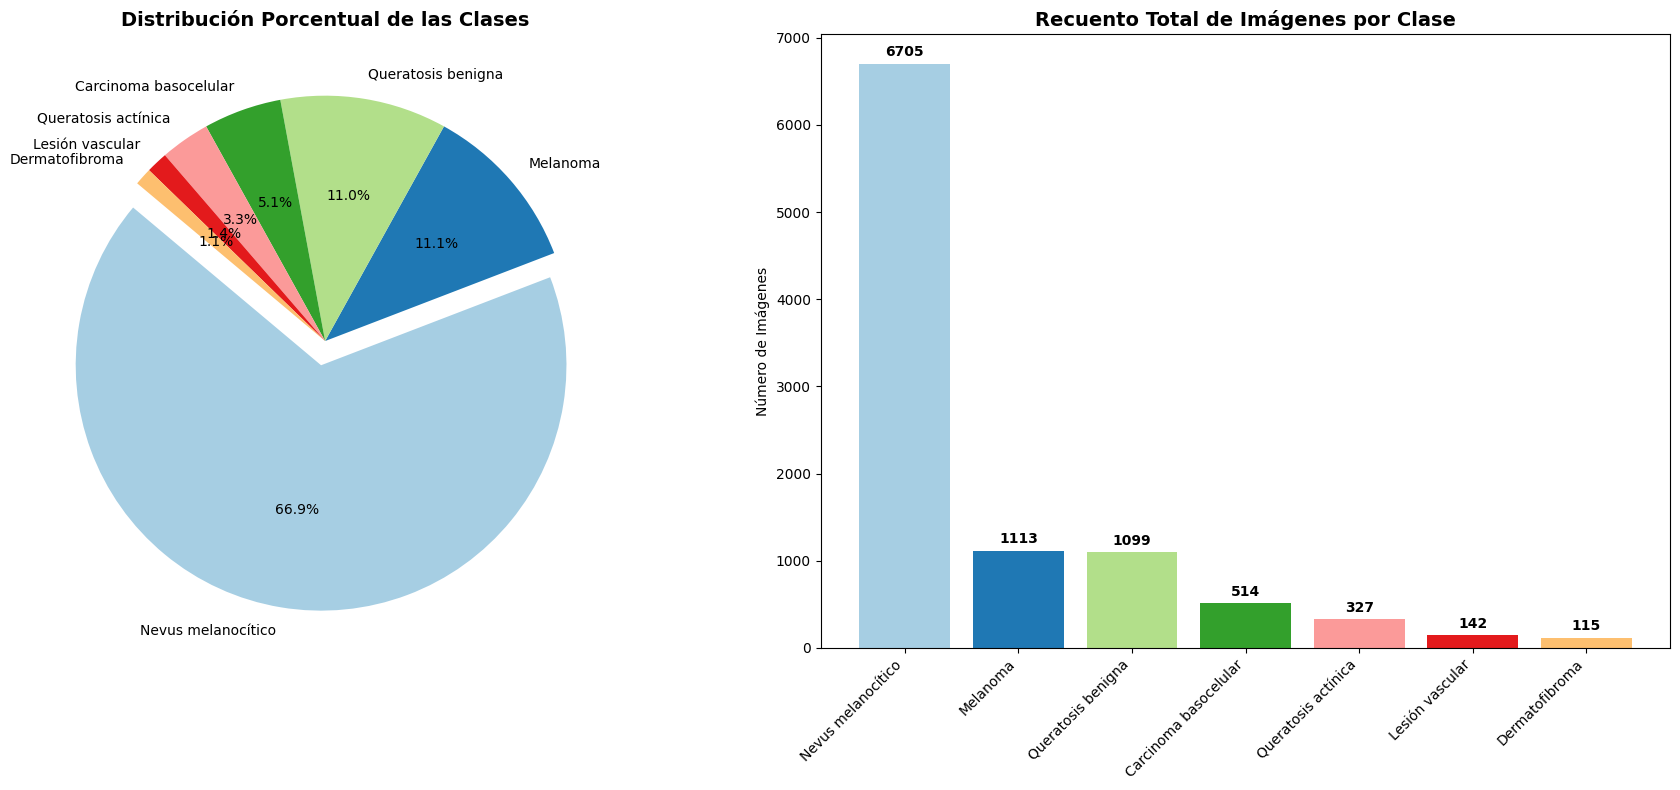


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [10]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

Vamos a compensar las clases:

/tmp/ipykernel_476471/2243536674.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Clase', data=df_weights, palette='viridis', ax=ax1)


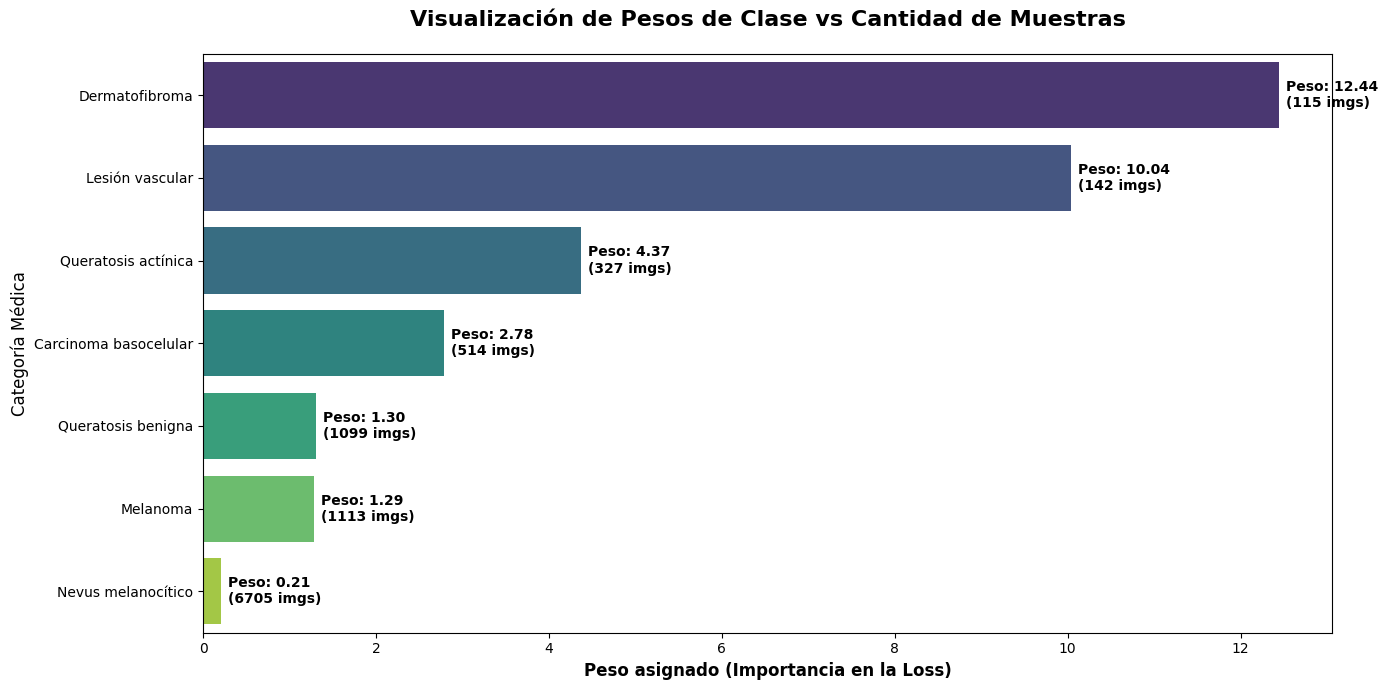

✅ Pesos calculados y listos para inyectar en model.fit(..., class_weight=dict_weights)


In [11]:
from sklearn.utils import class_weight
import seaborn as sns

# 1. Calcular los pesos (basado en lo que ya tienes en el notebook)
# train_labels son los IDs numéricos (0-6)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
dict_weights = dict(enumerate(weights))

# 2. Preparar datos para el gráfico
# Usamos class_names_es para que sea legible
df_weights = pd.DataFrame({
    'Clase': class_names_es,
    'Peso': weights,
    'Cantidad': [all_labels.count(i) for i in range(len(class_names))]
}).sort_values(by='Peso', ascending=False)

# 3. Visualización
fig, ax1 = plt.subplots(figsize=(14, 7))

# Gráfico de barras para los Pesos
sns.barplot(x='Peso', y='Clase', data=df_weights, palette='viridis', ax=ax1)
ax1.set_title('Visualización de Pesos de Clase vs Cantidad de Muestras', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Peso asignado (Importancia en la Loss)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Categoría Médica', fontsize=12)

# Añadir etiquetas de texto con la cantidad original para comparar
for i, p in enumerate(ax1.patches):
    cantidad = df_weights.iloc[i]['Cantidad']
    peso = df_weights.iloc[i]['Peso']
    ax1.annotate(f"Peso: {peso:.2f}\n({int(cantidad)} imgs)", 
                 (p.get_width(), p.get_y() + p.get_height()/2),
                 xytext=(5, 0), textcoords='offset points', 
                 va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Pesos calculados y listos para inyectar en model.fit(..., class_weight=dict_weights)")

## 6: Pipeline de entrenamiento con CoAtNet-0

In [12]:
from keras_cv_attention_models import coatnet

def build_hybrid_coatnet(img_shape=(224, 224, 3), meta_shape=(27,), dropout_rate=0.3, dense_units=256):
    img_input = tf.keras.Input(shape=img_shape, name="image_input")
    base_vision = coatnet.CoAtNet0(input_shape=img_shape, num_classes=0, pretrained="imagenet")
    x_img = base_vision(img_input)
    x_img = tf.keras.layers.GlobalAveragePooling2D()(x_img)

    meta_input = tf.keras.Input(shape=meta_shape, name="meta_input")
    x_meta = tf.keras.layers.Dense(32, activation='relu')(meta_input)
    x_meta = tf.keras.layers.Dense(16, activation='relu')(x_meta)

    combined = tf.keras.layers.Concatenate()([x_img, x_meta])
    
    # Aquí usamos los parámetros que nos pasa Optuna
    x = tf.keras.layers.Dense(dense_units, activation='relu')(combined)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    output = tf.keras.layers.Dense(7, activation='softmax')(x)

    return tf.keras.Model(inputs=[img_input, meta_input], outputs=output)

model = build_hybrid_coatnet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("✅ Modelo CoAtNet-0 cargado y compilado con éxito.")
# model.summary()

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
✅ Modelo CoAtNet-0 cargado y compilado con éxito.


## 7: Entrenamiento

Primero configuramos Optuna como optimizador:

In [13]:
import optuna
from sklearn.utils import class_weight

# 1. Configuración de la persistencia
storage_name = "sqlite:///optuna_tfm.db"
study_name = "hybrid_coatnet_optimization"

# Creamos o cargamos el estudio
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="maximize",
    load_if_exists=True
)

print(f"✅ Optuna DB lista en {storage_name}")

[I 2026-04-30 04:54:53,039] Using an existing study with name 'hybrid_coatnet_optimization' instead of creating a new one.


✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [14]:
from optuna_integration import TFKerasPruningCallback
import gc
import datetime

class TimestampCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\n⏰ Inicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"✅ Fin Época {epoch + 1}: {hora_actual}")

# Instanciamos el objeto
timestamp_cb = TimestampCallback()

def objective(trial):
    # 1. Hiperparámetros
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    dropout_val = trial.suggest_float("dropout", 0.3, 0.6)
    units = trial.suggest_categorical("dense_units", [128, 256, 512])
    
    # 2. Construcción
    model = build_hybrid_coatnet(
        dropout_rate=dropout_val, 
        dense_units=units,
        meta_shape=(len(train_meta[0]),)
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 3. Entrenamiento con Pruning
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=7, 
        class_weight=dict_weights,
        callbacks=[TFKerasPruningCallback(trial, "val_accuracy"), timestamp_cb],
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    
    # Limpieza de VRAM
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    
    return val_acc

Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.INFO)

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = True    # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = False  # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRIALS = 10                                                                                         
checkpoint_path = "models/hybrid_coatnet_v1.h5"

# 1. EJECUCIÓN DE OPTUNA (Solo si no saltamos entrenamiento y queremos optimizar)
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    # La función 'objective' debe estar definida en la celda anterior
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")

# 2. SELECCIÓN DE PARÁMETROS (De la DB de Optuna o Hardcoded)
if len(study.trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna: {best_params}")
else:
    best_params = {'learning_rate': 1e-4, 'dropout': 0.3, 'dense_units': 256}
    print(f"⚠️ No hay historial en la DB. Usando parámetros por defecto: {best_params}")

# 3. CONSTRUCCIÓN Y COMPILACIÓN FINAL
# Usamos los 'best_params' ya sea que vengan de una optimización recién hecha o de una anterior
model = build_hybrid_coatnet(
    dropout_rate=best_params['dropout'],
    dense_units=best_params['dense_units'],
    meta_shape=(len(train_meta[0]),)
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. LÓGICA DE CARGA O ENTRENAMIENTO FINAL
model_exists = os.path.exists(checkpoint_path)

if SKIP_TRAINING and model_exists:
    print(f"📦 MODO SKIP: Cargando pesos desde {checkpoint_path}")
    model.load_weights(checkpoint_path)
    history = None
else:
    if SKIP_TRAINING and not model_exists:
        print("⚠️ Aviso: SKIP_TRAINING es True pero no hay .h5. Forzando entrenamiento...")
    
    print(f"🚀 Iniciando entrenamiento final con {best_params}...")
    
    os.makedirs("models", exist_ok=True)
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )

    # Entrenamiento completo con pesos de clase para el desbalanceo
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=dict_weights,
        callbacks=[checkpoint_callback]
    )

📈 Usando mejores parámetros encontrados por Optuna: {'learning_rate': 3.658031280771968e-05, 'dropout': 0.49864238634537517, 'dense_units': 512}
>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
⚠️ Aviso: SKIP_TRAINING es True pero no hay .h5. Forzando entrenamiento...
🚀 Iniciando entrenamiento final con {'learning_rate': 3.658031280771968e-05, 'dropout': 0.49864238634537517, 'dense_units': 512}...
Epoch 1/15


2026-04-30 05:33:20.502773: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1777523603.448609  476963 service.cc:145] XLA service 0x73dd1d714600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777523603.448665  476963 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-04-30 05:33:23.463364: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777523603.585181  476963 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/251 [==============================] - ETA: 0s - loss: 1.3423 - accuracy: 0.5161
Epoch 1: val_accuracy improved from -inf to 0.69546, saving model to models/hybrid_coatnet_v1.h5


/home/herraiz/miniconda3/envs/tfm_linux/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


251/251 [==============================] - 101s 257ms/step - loss: 1.3423 - accuracy: 0.5161 - val_loss: 0.8143 - val_accuracy: 0.6955
Epoch 2/15
251/251 [==============================] - ETA: 0s - loss: 0.6625 - accuracy: 0.6985
Epoch 2: val_accuracy improved from 0.69546 to 0.72841, saving model to models/hybrid_coatnet_v1.h5
251/251 [==============================] - 63s 252ms/step - loss: 0.6625 - accuracy: 0.6985 - val_loss: 0.6728 - val_accuracy: 0.7284
Epoch 3/15
251/251 [==============================] - ETA: 0s - loss: 0.4432 - accuracy: 0.7635
Epoch 3: val_accuracy improved from 0.72841 to 0.74538, saving model to models/hybrid_coatnet_v1.h5
251/251 [==============================] - 62s 245ms/step - loss: 0.4432 - accuracy: 0.7635 - val_loss: 0.6158 - val_accuracy: 0.7454
Epoch 4/15
251/251 [==============================] - ETA: 0s - loss: 0.2493 - accuracy: 0.8300
Epoch 4: val_accuracy improved from 0.74538 to 0.85072, saving model to models/hybrid_coatnet_v1.h5
251/251 [

## 8: Predicciones (Preparación de datos)
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [17]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

# 1. Generamos las de ENTRENAMIENTO (las que te faltaban)
y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")

# 2. Generamos las de VALIDACIÓN
y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")

print(f"✅ Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes.")

🔮 Generando predicciones sobre el set de ENTRENAMIENTO...


2026-04-30 07:27:07.951865: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de VALIDACIÓN...
✅ Análisis completado. Entrenamiento: 8012 imágenes | Validación: 2003 imágenes.


2026-04-30 07:27:14.311346: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [18]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Accuracy Global
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)

print("="*60)
print(f"📈 RENDIMIENTO GLOBAL (Modelo Híbrido)")
print(f"   - Accuracy Entrenamiento: {acc_train:.4f}")
print(f"   - Accuracy Validación:    {acc_val:.4f}")
print("="*60)

# 2. Reporte Detallado de Validación
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):")
print(classification_report(y_true_val, y_pred_val, target_names=class_names_es))

# 3. Reporte Detallado de Entrenamiento
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):")
print(classification_report(y_true_train, y_pred_train, target_names=class_names_es))

📈 RENDIMIENTO GLOBAL (Modelo Híbrido)
   - Accuracy Entrenamiento: 0.9955
   - Accuracy Validación:    0.8887

📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
                       precision    recall  f1-score   support

  Queratosis actínica       0.88      0.78      0.83        65
Carcinoma basocelular       0.84      0.88      0.86       103
   Queratosis benigna       0.83      0.75      0.79       220
       Dermatofibroma       0.76      0.70      0.73        23
   Nevus melanocítico       0.92      0.96      0.94      1341
             Melanoma       0.73      0.62      0.67       223
      Lesión vascular       0.93      0.89      0.91        28

             accuracy                           0.89      2003
            macro avg       0.84      0.80      0.82      2003
         weighted avg       0.88      0.89      0.89      2003


📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
                       precision    recall  f1-score   support

  Queratosis actínica  

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

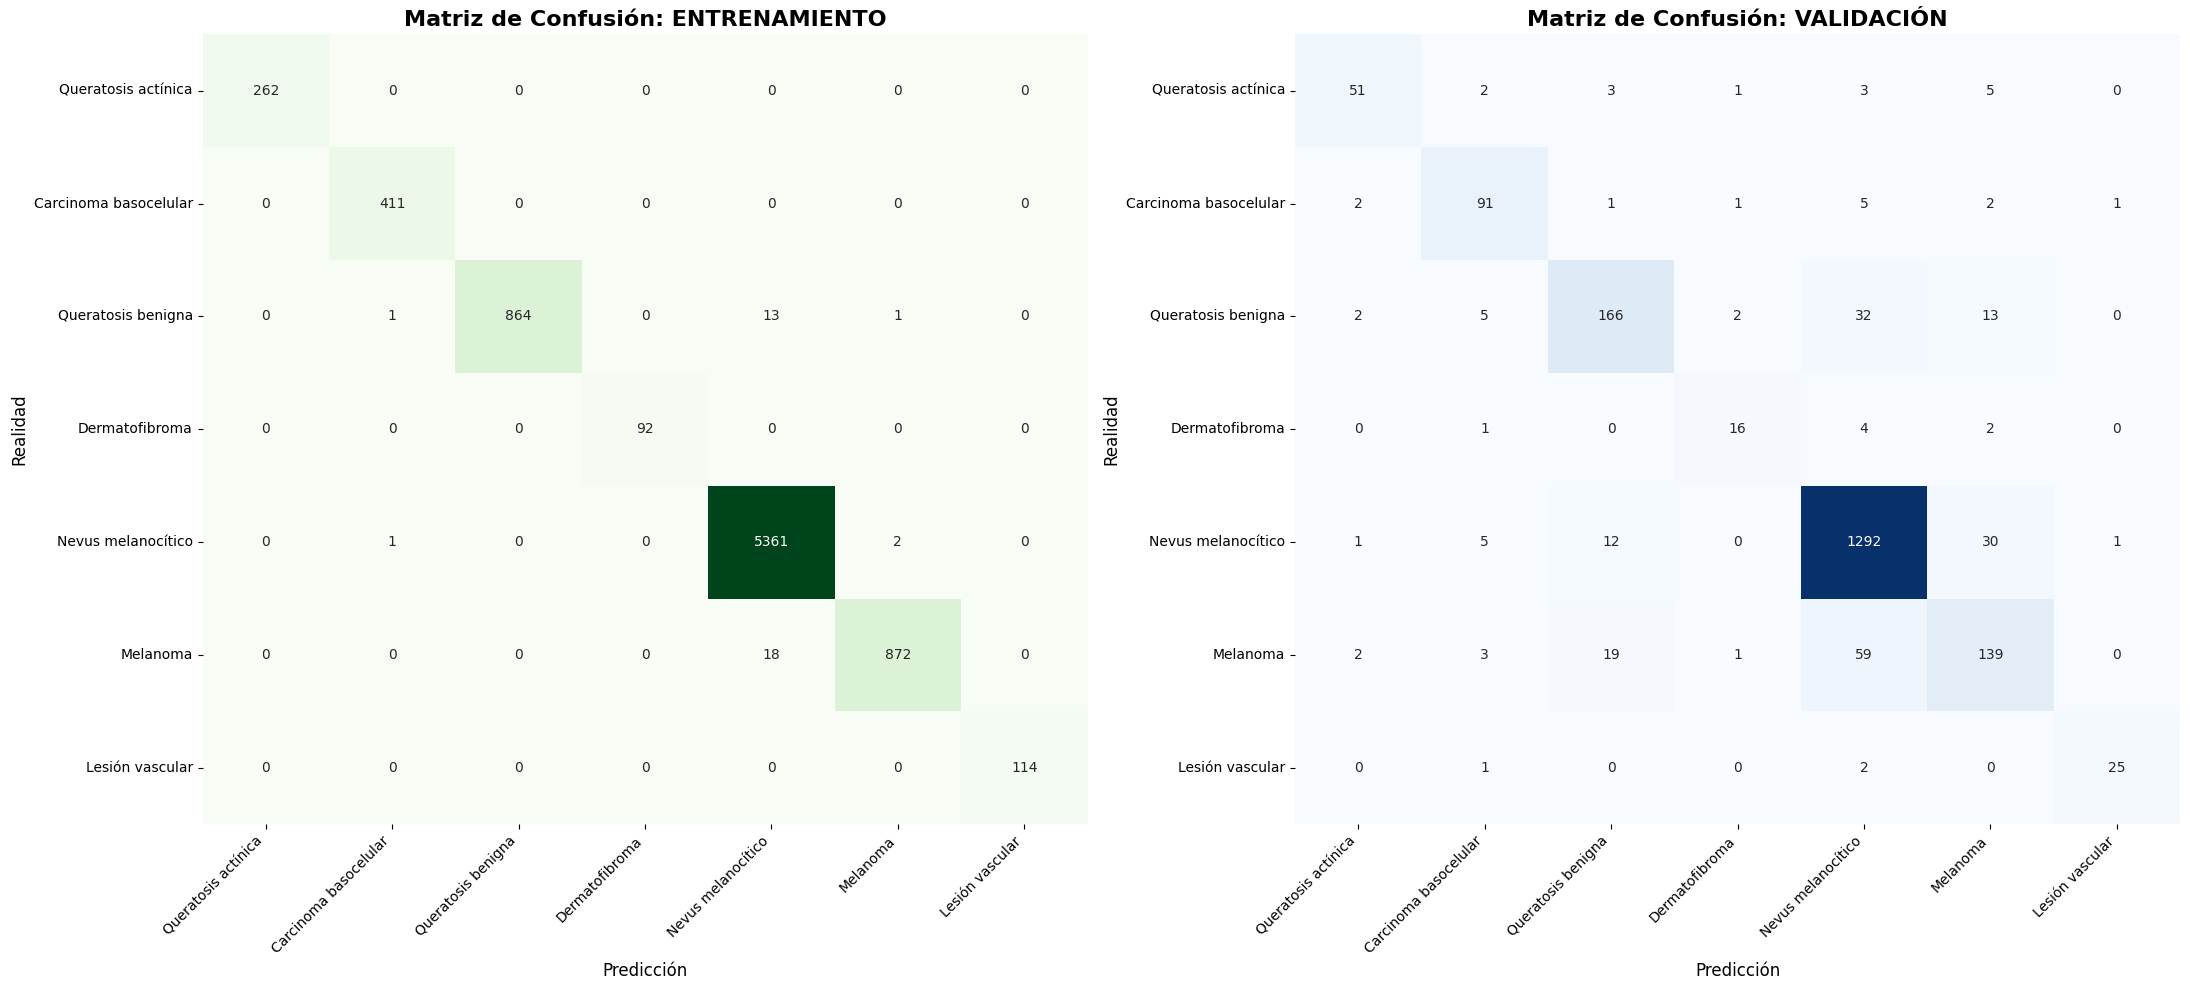

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)

# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 2, figsize=(22, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.

📊 Generando comparativa XAI (Grad-CAM, LIME, SHAP) para el modelo híbrido...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

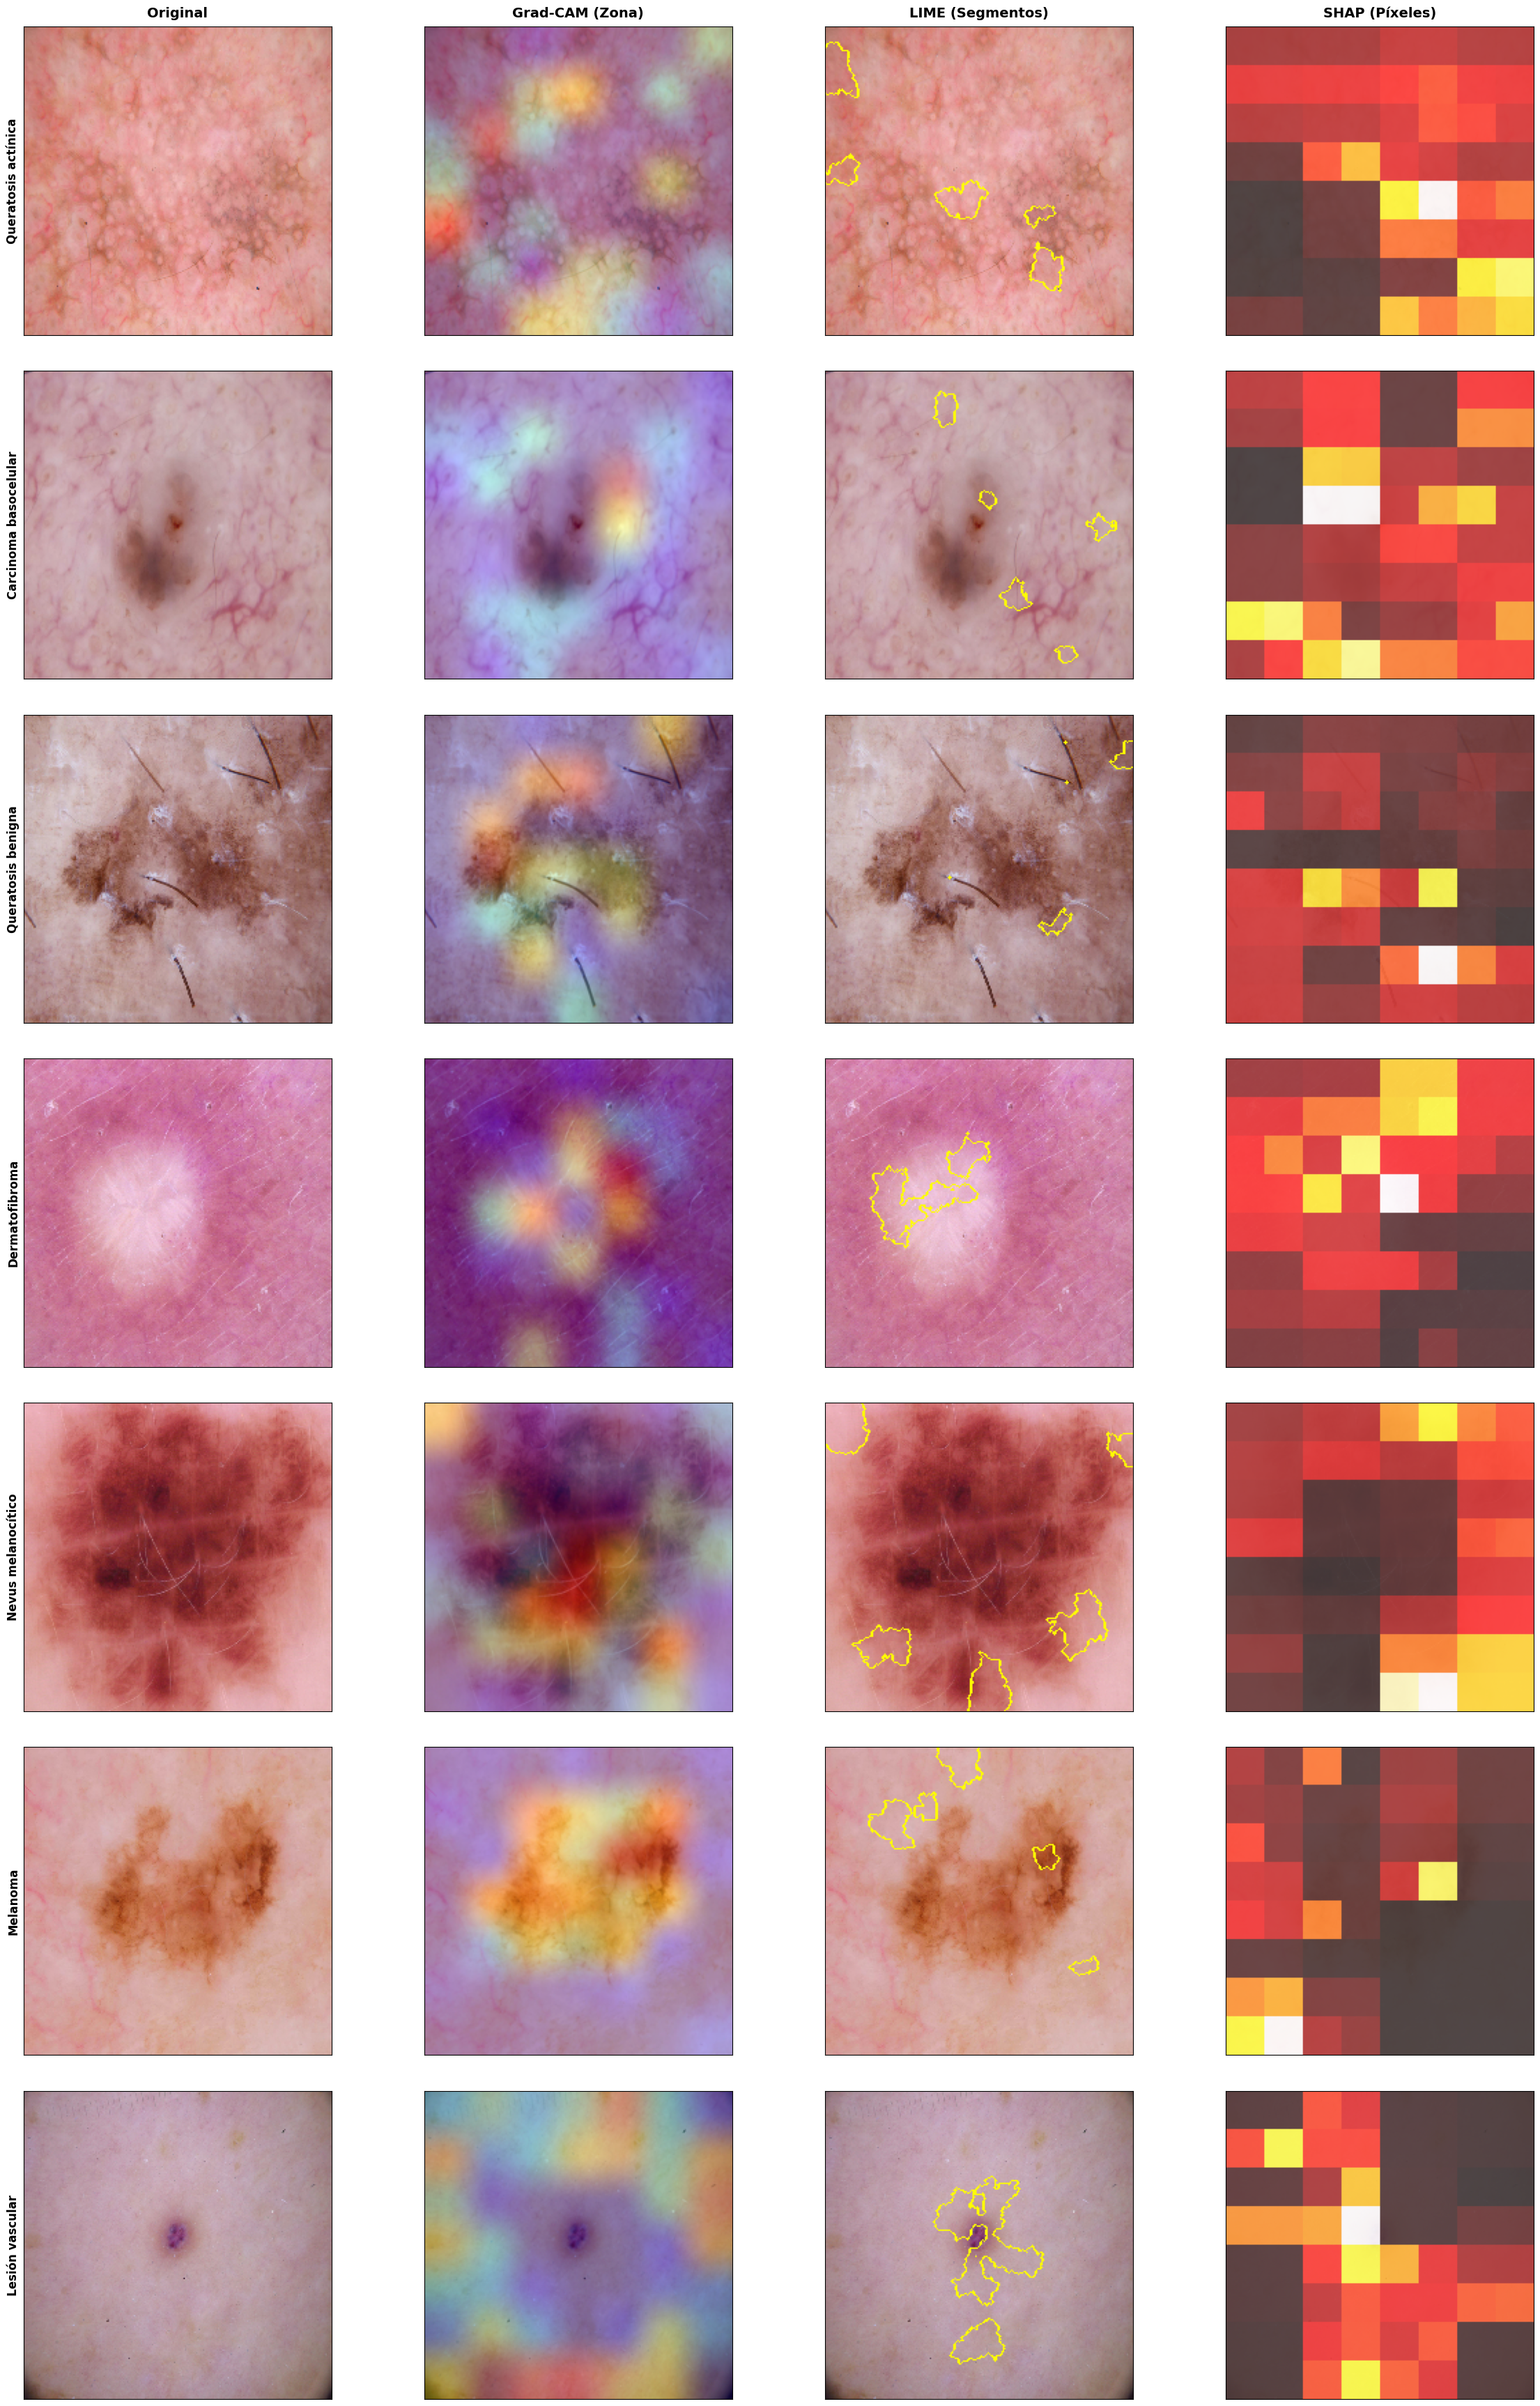

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import random
import contextlib
import tensorflow as tf
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift

# --- 1. FUNCIONES CORE ADAPTADAS ---

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    """
    Genera Grad-CAM para modelos híbridos atacando directamente al backbone de visión.
    """
    # Accedemos al sub-modelo de visión (la caja de CoAtNet)
    v_model = model.get_layer('coatnet0')
    
    # Creamos un modelo que mapee desde la entrada de visión a la capa conv y la salida de visión
    grad_model = tf.keras.models.Model(
        [v_model.inputs], 
        [v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )

    with tf.GradientTape() as tape:
        # Aquí solo pasamos la imagen al sub-modelo
        conv_output, vision_preds = grad_model(img_array)
        # Usamos el índice que predijo el modelo COMPLETO
        class_channel = vision_preds[:, pred_index]

    # Gradientes y pesos
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# --- 2. CONFIGURACIÓN Y BUCLE PRINCIPAL ---

print("📊 Generando comparativa XAI (Grad-CAM, LIME, SHAP) para el modelo híbrido...")

# Identificar capa convolucional dentro del sub-modelo
sub_model = model.get_layer('coatnet0')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]
explainer_lime = lime_image.LimeImageExplainer()

n_clases = len(class_names)
fig, axes = plt.subplots(nrows=n_clases, ncols=4, figsize=(22, 5 * n_clases))
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

# Silenciamos la verbosidad de SHAP y LIME
with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    for i, nombre_clase in enumerate(class_names):
        # A. Selección de imagen y metadatos
        class_dir = os.path.join(DATA_PATH, nombre_clase)
        img_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, img_name)
        img_id = img_name.replace('.jpg', '')
        
        # Extraer metadatos reales de esa imagen específica
        current_meta = df_meta_ready.loc[[img_id]].values.astype('float32')
        
        # B. Preparación de imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0

        # C. WRAPPER PARA LIME/SHAP (Inyecta metadatos fijos en cada batch de perturbaciones)
        def hybrid_predict(batch):
            m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
            return model.predict([batch, m_batch], verbose=0)

        # 1. Ejecutar Predicción del modelo completo
        full_pred = model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(full_pred[0])

        # 2. Grad-CAM
        h_map = get_gradcam_heatmap(img_input, model, last_conv_name, pred_idx)
        gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
        
        # 3. LIME
        exp = explainer_lime.explain_instance(
            img_input[0].astype('double'), hybrid_predict, 
            top_labels=1, num_samples=500,
            segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
        )
        temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
        
        # 4. SHAP
        masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
        expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
        sv = expl_shap(img_input, max_evals=200, batch_size=50)
        abs_s = np.abs(sv.values[0, :, :, :, pred_idx]).sum(axis=-1)

        # --- RENDERIZADO ---
        
        # Original
        axes[i, 0].imshow(img_raw)
        axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
        
        # Grad-CAM
        axes[i, 1].imshow(gcam_res)
        
        # LIME
        axes[i, 2].imshow(mark_boundaries(temp, mask))
        
        # SHAP
        axes[i, 3].imshow(img_raw, alpha=0.3)
        axes[i, 3].imshow(abs_s, cmap='hot', alpha=0.7)

        # Limpiar ejes y poner títulos en la primera fila
        for j in range(4):
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
            if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()